**Group :**

Armand GHIONDA
Abdessalam AITHAQI

## Advice
### Work
- **Read the whole subject before starting**
- Search for the documentation (Google) before asking a teacher
- The work will be evaluated based on this notebook:
    - Answer questions in the notebook.
    - Insert your code here and execute it so that the output stays displayed for the teacher.

### ChatGPT
- You can use ChatGPT ONLY to answer specific questions, get introductory explanations on machine learning libraries, get example codes. Be aware that there is no guaranty in the answer of ChatGPT (even with the paying licence).
- Do not use ChatGPT to work in your stead ! The goal is for you to learn the manipulation of machine learning basic methods yourself. Teachers are used to look at student's works and ChatGPT is not good to fake it.
=> In case of a doubt of ChatGPT use (or plagiarism between groups), the students will be summoned and evaluated on an oral presentation.

# Lab: Classification with Decision Trees

**Objectives of the practical work:**

1. Learn how to build decision trees with scikit-learn
2. Be familiar with some parameters and visualization tools
3. Use a real-case dataset (COMPASS ) as an example
4. Evaluate diverse trees in terms of training and testing accuracies with different parameters
5. Study the impact of some parameters on the sensitivity aspect




## PART 1: Basic steps

The following are basic instructions to start with decision trees. You need to execute them one by one to understand the basic steps for learning decision trees. Once you get familiar with the different steps, you will be working on the compass dataset.

The decision tree package that we use is from scikit-learn. The full documentation of decision trees are available at https://scikit-learn.org/stable/modules/tree.html

Take a moment to briefly consult the documentation.

We need first to include some libraries:




In [1]:
from sklearn import tree
from matplotlib import pyplot as plt # for a good visualization of the trees

The following is a basic example for binary classification



In [ ]:
# X is the training set
# Each example in X has 4 binary features
X = [[0, 0, 1, 0], [0, 1, 0, 1] , [1, 1, 0, 0] , [1, 0, 1, 1] , [0, 0, 0, 1] , [1, 1, 1, 0]]

# Y is the classes associated with the training set.
# For instance the label of the first and second example is 1; of the third example is 0, etc
Y = [1, 1, 0, 0, 1, 1]

We construct a decision tree using the default parameters:

In [ ]:
clf = tree.DecisionTreeClassifier()
clf = clf.fit(X, Y)

Now we can ask the decision tree to predict the outcome for unknown examples.
For instance we can ask a prediction for the three examples:

In [ ]:
clf.predict([[1,1,1,1] , [0,1,0,0] , [1,1,0,1] ])

The result is an array of the 3 predicted labels (one for each example): `array([0, 1, 0])`

## PART 2 : Visualization

There are many ways to visualize a decision tree. The first one is very basic:



In [ ]:
text_representation = tree.export_text(clf)
print(text_representation)



We can use a more readable and visual way as follows:

In [ ]:
fig = plt.figure(figsize=(10,7))
_ = tree.plot_tree(clf,
        feature_names= ("f1","f2" , "f3", "f4"),
        class_names= ("false (0)", "true (1)" ),
        filled=True)

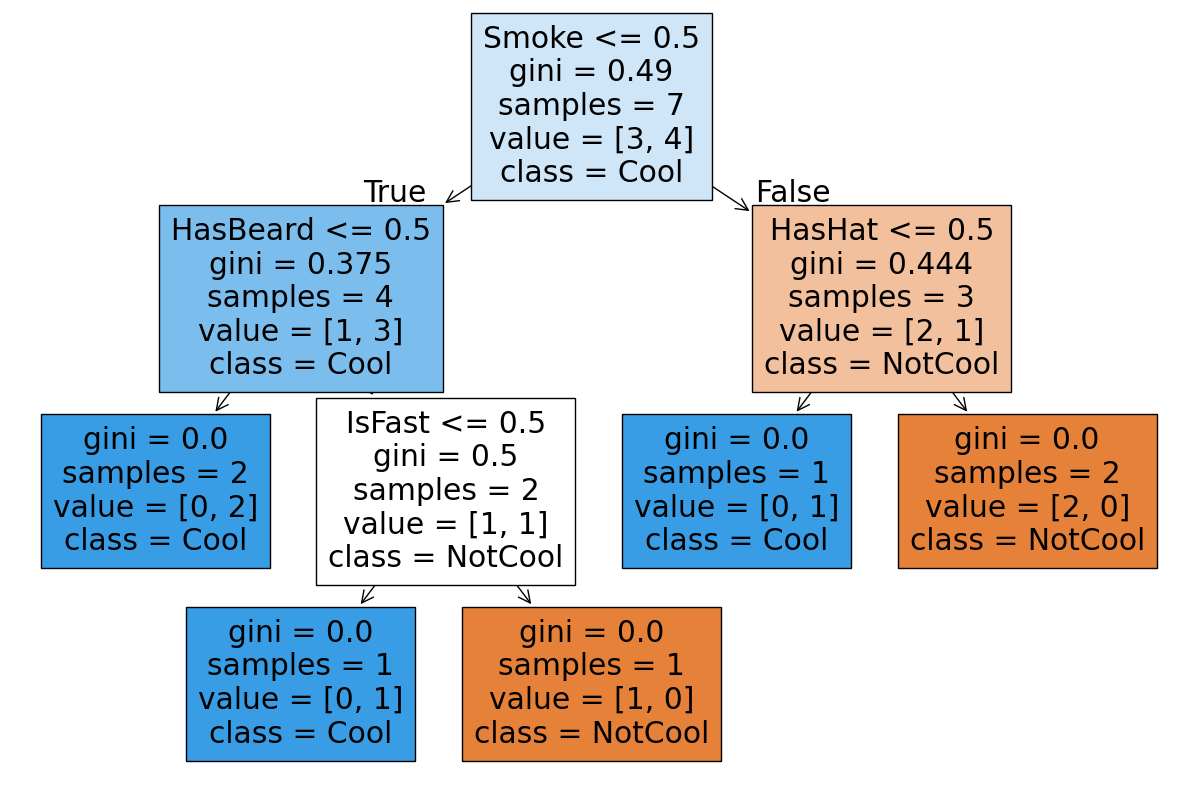

In [2]:
#Construction du nouveau dataset (question d'avant)

X2 = [
    [0, 0, 1, 0, 0, 0, 1, 1],
    [0, 1, 0, 1, 0, 1, 0, 0],
    [1, 1, 0, 0, 0, 1, 1, 0],
    [1, 0, 1, 1, 1, 1, 0, 1],
    [0, 0, 0, 1, 0, 0, 1, 0],
    [1, 1, 1, 0, 1, 0, 0, 1],
    [0, 1, 1, 1, 1, 0, 1, 1]
]
Y2 = [1, 1, 0, 0, 1, 1, 0]

feature_names = (
    "HasHat", "IsSmiling", "WearingSunGlasses", "IsTall",
    "HasBeard", "Smoke", "IsFast", "LikesBeer"
)
class_names = ("NotCool", "Cool")

clf2 = tree.DecisionTreeClassifier()
clf2 = clf2.fit(X2, Y2)

fig = plt.figure(figsize=(15, 10))
_ = tree.plot_tree(clf2,
        feature_names=feature_names,
        class_names=class_names,
        filled=True)

Where:
- `figsize` restrains the size of the plot,
- `feature_names` gives the names of the different features,
- `class_names` corresponds to human readable labels for each class,
- `filled` is a boolean indicating a preference to show a colorful tree.


**Tasks:**
- Construct manually a new binary dataset (larger than the one above), associate some labels then study the tree built by default (similar to above). Give some fancy names to the binary features and classes for a visual interpretation. Be quick, the constructed dataset does NOT need to make sense.



## PART 3: The compass dataset

We study here the COMPASS dataset as a case study. Recall that it has been used in a legislative context for predicting recidivism in the U.S. That is, the tendency of a convicted criminal to re-offend


Have a look at the original non-binary dataset ([https://www.kaggle.com/danofer/compass](https://www.kaggle.com/danofer/compass)) to understand the different features. Consider in particular the data used for fairness: propublicaCompassRecividism_data_fairml.csv


**Understanding the dataset (from Kaggle) :**

Take a moment to think about the following questions

- What are the features?
- How many examples in the dataset?
- What are your expectations regarding the most important features?
- Propose (informally) a way to reduce the dataset
- There many ways to binarize the dataset. How do you propose to do so?

**Understanding the dataset (from Kaggle) :**

Take a moment to think about the following questions

- What are the features: 
    race_African-American,
    race_Caucasian,
    age_high,
    age_low,
    age_middle,
    age_very_high,
    age_very_low,
    priors_count_high,
    priors_count_low,
    priors_count_middle,
    priors_count_very_low,
    juv_fel_count_4,
    juv_misd_count_1,
    juv_other_count_1,
    juv_other_count_17,
    juv_fel_count_9,
    juv_fel_count_10,
    juv_fel_count_3,
    juv_other_count_0,
    juv_misd_count_0,
    juv_fel_count_6,
    juv_fel_count_0,
    juv_misd_count_3,
    juv_other_count_4,
    juv_misd_count_6,
    juv_other_count_5,
    juv_misd_count_2,
    juv_misd_count_13,
    juv_misd_count_8,
    juv_misd_count_5,
    sex_Male,
    juv_misd_count_4,
    juv_other_count_2,
    juv_fel_count_2,
    juv_other_count_3,
    sex_Female,
    juv_fel_count_1,
    juv_misd_count_12,
    juv_fel_count_5,
    c_charge_degree_Misdemeanor,
    juv_other_count_6,
    c_charge_degree_Felony,
    juv_other_count_7,
    juv_fel_count_8,
    two_year_recid

- How many examples in the dataset: 
    6 150 examples

- What are your expectations regarding the most important features :
    We expect that the most important features should be priors_count, age, juvenile-history variables, and charge degree. These are the most directly related to prior behavior and offense severity, so they should carry the strongest predictive signal.
- Propose (informally) a way to reduce the dataset :
    We could reduce the dataset by merging categories that have sparse counts into broader bins. Another good reduction would be removing sensitive discriminatory features such as race and sex.
- There many ways to binarize the dataset. How do you propose to do so :
    We propose to binarize in the same way it already is meaning one-hot encoding. a good bin would be age and priors_count. For instance, we could create binary features for age groups (e.g., age_low, age_middle, age_high) and for priors_count (e.g., priors_count_low, priors_count_middle, priors_count_high). This way, we can capture the non-linear relationships between these features and the target variable while keeping the dataset manageable.

**Analysing the dataset with machine learning (custom binarized dataset, NOT from Kaggle) :**

Below, we use a binarized version of the dataset that is used in the FairCORELS library (https://github.com/ferryjul/fairCORELS) as well some of its tools.

You need first to download the dataset and the tools file and put them in your work directory:

- The dataset [compass.csv](compass.csv)
- The set of tools [utils.py](utils.py)

Load the binary dataset `compass.csv` as follows

In [ ]:
import csv
import numpy as np
from utils import load_from_csv

train_examples, train_labels, features, prediction = load_from_csv("./compass.csv")

Inspect each of these 4 objects.
What do they represent? How many features? examples?
We want to predict recidivism after 2 years, where is this information stored ?

Have a look at the different parameters of the `DecisionTreeClassifier` class constructor. We will be studying three parameters:
- splitter
- max_depth
- min_samples_leaf

What do they represent?

## EVALUATED PART:

In the following, we consider the  (binarized) Compas dataset that we studied in the Lab

Q1: A decision tree configuration is a set of parameters that one can use to build decision trees. Propose 6 configurations that are likely to provide different topologies and caracteristics.

Q2: Train a decision tree for each of the previous configurations on the full dataset. Run a train-test evaluation on different trees (with different parameters) by randomly splitting the data 80% for training and 20% for test *multiple times*. Vizualize the resulting decision trees.

Q3: Propose an evaluation in terms of training and testing accuracies using $5$-cross validation on two decision trees that have different topologies

Q4: Propose an experimental study that shows the transition phase from underfitting to overfitting. Evaluate the impact (in terms of accuracy) of the three parameters : maximum depth, splitting criterion, and the minimum sample leafs.

Q5: Construct the confusion matrix on a particular good configuration (after explaining your choice). What are the most important parameters in terms of True/False Positive/Negative Rate?

Q6: Provide an evaluation of the fairness of the model based on the False Positive Rate. The "utils.py" file provides useful functions for this purpose.